# **PROJECT: Market Basket + Bundle Profit Simulation**
Dataset: Jordan1_Datos.csv

Materiales Jordan is a company with over 30 years of experience in the Mexican heavy construction materials market. Its product range extends from steel (rebar, wire rod, and wire) to cement and concrete.
They hired us as external consultants to answer a specific question: which products can be bundled in a way that customers are willing to pay for?

The project's objective was to provide stakeholders with a deeper understanding of customer behavior and product interactions, and to develop viable strategies capable of strengthening profit margins.
### Goal: rules (A->B) + expected incremental profit with discount

In [28]:

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules


In [29]:
df = pd.read_csv("/content/drive/MyDrive/Proyectos/Jordan1_Datos.csv")

# Cleaning and Standarization

In [30]:
def canon_id(x):  #Avoiding canonicalize IDs
    return (
        str(x)
        .strip()
        .lower()
        .replace("{", "")
        .replace("}", "")
        .replace('"', "")
        .replace("'", "")
    )

df["product_id"] = df["product_id"].apply(canon_id)

df["product_name"] = (
    df["product_name"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip())

In [31]:
df["product_price_catalog"] = pd.to_numeric(df["product_price_catalog"], errors="coerce")
df["product_cost_price"] = pd.to_numeric(df["product_cost_price"], errors="coerce")
df["product_price"] = pd.to_numeric(df["product_price"], errors="coerce")

# profitability:
df["price_used"] = df["product_price_catalog"].fillna(df["product_price"])
df["cost_used"] = df["product_cost_price"]

# Unit profit
df["unit_profit_used"] = df["price_used"] - df["cost_used"]

# DataSet Exploration

In [32]:
df["product_price_catalog"] = pd.to_numeric(df["product_price_catalog"], errors="coerce")
df["product_cost_price"] = pd.to_numeric(df["product_cost_price"], errors="coerce")
df["product_price"] = pd.to_numeric(df["product_price"], errors="coerce")

# Official price used for profitability:
df["price_used"] = df["product_price_catalog"].fillna(df["product_price"])
df["cost_used"] = df["product_cost_price"]

# Unit profit with chosen price/cost
df["unit_profit_used"] = df["price_used"] - df["cost_used"]

In [33]:
#DataSet Atributes
n_sales = df["sale_id"].nunique()
n_items = df["product_id"].nunique()
avg_items_per_sale = len(df) / n_sales if n_sales else float("nan")

print("Rows:", df.shape)
print("Unique sales:", n_sales)
print("Unique products:", n_items)
print("Avg items per sale:", round(avg_items_per_sale, 2))

Rows: (36448, 17)
Unique sales: 14780
Unique products: 139
Avg items per sale: 2.47


A Basket analysis is very usefull in this type of situations it uncovers patterns in customer purchasing behavior, identifying products frequently bought together. By analyzing these combinations, businesses can optimize product placement, enhance cross-selling/up-selling strategies, and improve marketing efforts to increase revenue and customer satisfaction

# Basket Construction

In [34]:
basket = df.groupby("sale_id")["product_id"].apply(list)  #Basket creation

te = TransactionEncoder()  #apriori needs of this type of format.
basket_df = pd.DataFrame(te.fit(basket).transform(basket), columns=te.columns_)

print("Basket matrix shape:", basket_df.shape)

#------------------------------#

MIN_SUPPORT = 0.02   #2% of the unique sales ... 256 proxy
MAX_LEN = 3          # pairs + triplets

frequent_itemsets = apriori(
    basket_df,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=MAX_LEN
)
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)

print("Frequent itemsets:", frequent_itemsets.shape)


Basket matrix shape: (14780, 139)
Frequent itemsets: (55, 3)


In [35]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules = rules[(rules["confidence"] >= 0.30) & (rules["lift"] >= 1.20)].copy()

print("Rules:", rules.shape)


rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules = rules[(rules["confidence"] >= 0.30) & (rules["lift"] >= 1.20)].copy()

print("Rules:", rules.shape)



Rules: (19, 14)
Rules: (19, 14)


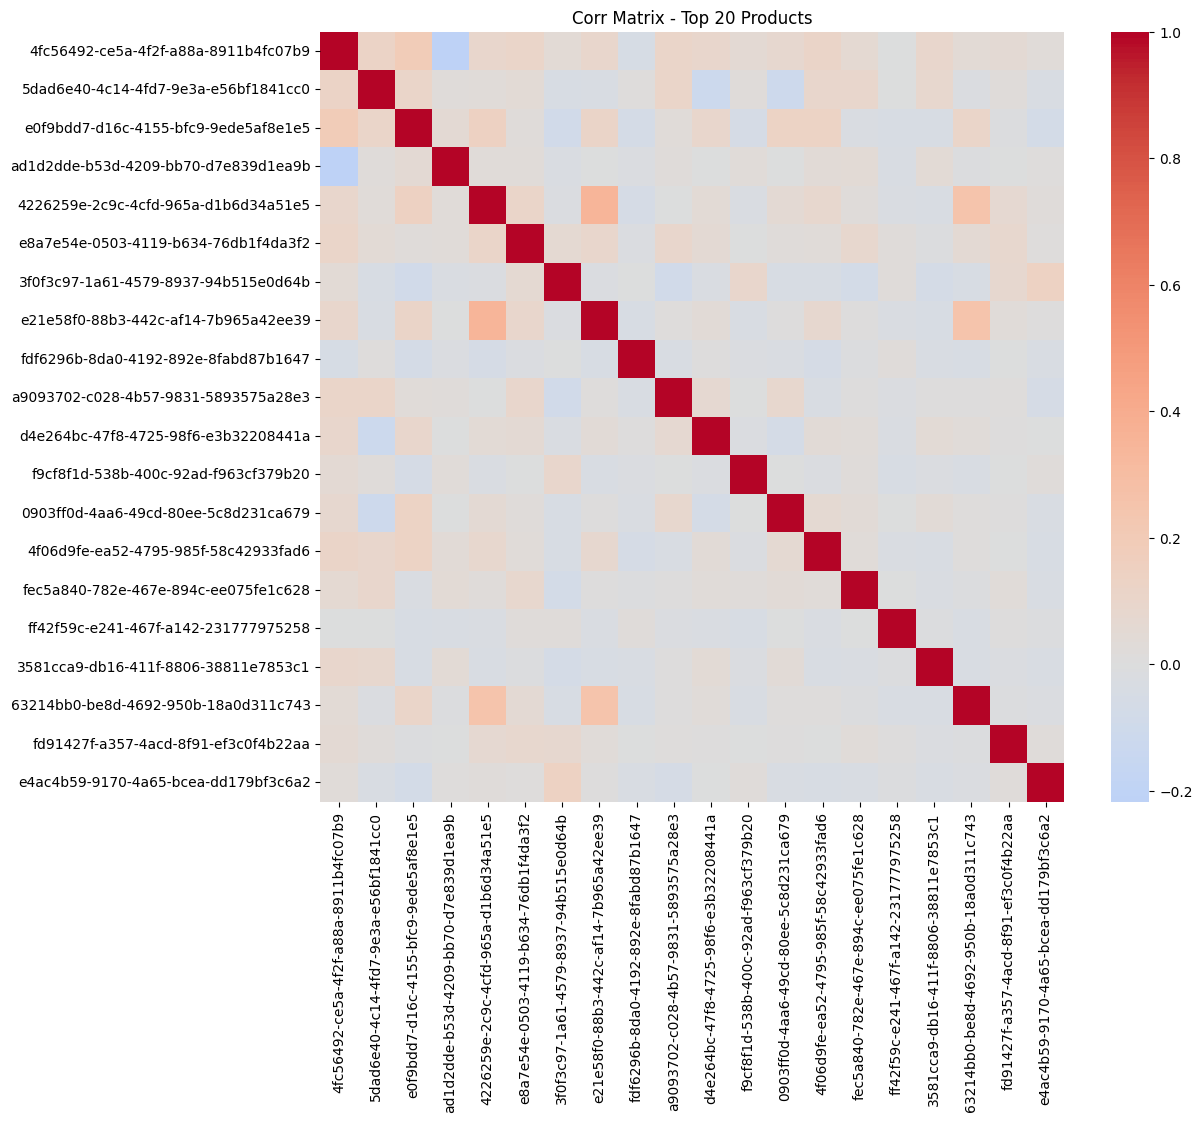

<Figure size 640x480 with 0 Axes>

In [36]:
# We will create the cormatrix visualization to confirm the existance of correlation between our products
#for strenghtening of basket model

basket = df.groupby("sale_id")["product_id"].apply(list)

te = TransactionEncoder()
basket_df = pd.DataFrame(te.fit(basket).transform(basket), columns=te.columns_)

corr_matrix = basket_df.corr()

top_products = df["product_id"].value_counts().head(20).index

corr_top = basket_df[top_products].corr()

plt.figure(figsize=(12,10))
sns.heatmap(
    corr_top,
    cmap="coolwarm",
    center=0,
    annot=False
)
plt.title("Corr Matrix - Top 20 Products")
plt.show()

plt.savefig("heatmap.png", dpi=150, bbox_inches="tight")


In [37]:
rules_1to1 = rules[
    (rules["antecedents"].apply(len) == 1) &
    (rules["consequents"].apply(len) == 1)
].copy()

rules_1to1["antecedent_id"] = rules_1to1["antecedents"].apply(lambda s: list(s)[0])
rules_1to1["consequent_id"] = rules_1to1["consequents"].apply(lambda s: list(s)[0])

print("Rules 1→1:", rules_1to1.shape)

Rules 1→1: (16, 16)


In [38]:
id_to_name = (
    df[["product_id", "product_name"]]
    .drop_duplicates()
    .set_index("product_id")["product_name"]
    .to_dict()
)

rules_1to1["antecedent_name"] = rules_1to1["antecedent_id"].map(lambda x: id_to_name.get(x, x))
rules_1to1["consequent_name"] = rules_1to1["consequent_id"].map(lambda x: id_to_name.get(x, x))


# Business Metrics

In [39]:
product_metrics = (
    df.groupby("product_id")
      .agg(
          avg_price=("price_used", "mean"),
          avg_cost=("cost_used", "mean")
      )
      .reset_index()
)

rules_1to1 = rules_1to1.merge(
    product_metrics,
    left_on="consequent_id",
    right_on="product_id",
    how="left"
)

# Debug: check missing economics after merge
print("\nMissing after merge (avg_price/avg_cost):")
print(rules_1to1[["avg_price", "avg_cost"]].isna().mean())



Missing after merge (avg_price/avg_cost):
avg_price    0.000
avg_cost     0.125
dtype: float64


In [40]:
DISCOUNT = 0.05  # Discount Simulation


rules_1to1["support_A"] = rules_1to1["support"] / rules_1to1["confidence"]

rules_1to1["expected_new_sales"] = (
    rules_1to1["support_A"] * n_sales * (1 - rules_1to1["confidence"])
).round(0)

# profit per unit with discount
rules_1to1["discounted_profit_per_unit"] = (rules_1to1["avg_price"] * (1 - DISCOUNT)) - rules_1to1["avg_cost"] # profit per unit with discount


rules_1to1["incremental_profit"] = rules_1to1["expected_new_sales"] * rules_1to1["discounted_profit_per_unit"]  # incremental profit


#TOP CANDIDATES

In [41]:

cols = [
    "antecedent_name", "consequent_name",
    "support", "confidence", "lift",
    "expected_new_sales",
    "avg_price", "avg_cost",
    "discounted_profit_per_unit",
    "incremental_profit"]
top_profit = rules_1to1.sort_values("incremental_profit", ascending=False)[cols].head(20)
print("\n=== TOP 20 by incremental_profit (5% discount on consequent) ===")
print(top_profit.to_string(index=False))



=== TOP 20 by incremental_profit (5% discount on consequent) ===
             antecedent_name                   consequent_name  support  confidence     lift  expected_new_sales  avg_price  avg_cost  discounted_profit_per_unit  incremental_profit
       ARENA #5 METRO CUBICO      CARGO POR ENTREGA 200 ZONA 1 0.023816    0.305291 1.813583               801.0 172.410000   100.000                     63.7895          51095.3895
CARGO POR ENTREGA 200 ZONA 1 CEMENTO GRIS MONTERREY EXTRA 50KG 0.065832    0.391077 1.449015              1515.0 245.690000   215.520                     17.8855          27096.5325
           VARILLA 3/8 PIEZA CEMENTO GRIS MONTERREY EXTRA 50KG 0.043099    0.387942 1.437397              1005.0 245.690000   215.520                     17.8855          17974.9275
              ARENA #5 BULTO CEMENTO GRIS MONTERREY EXTRA 50KG 0.031191    0.326950 1.211413               949.0 245.690000   215.520                     17.8855          16973.3395
                    BLOC

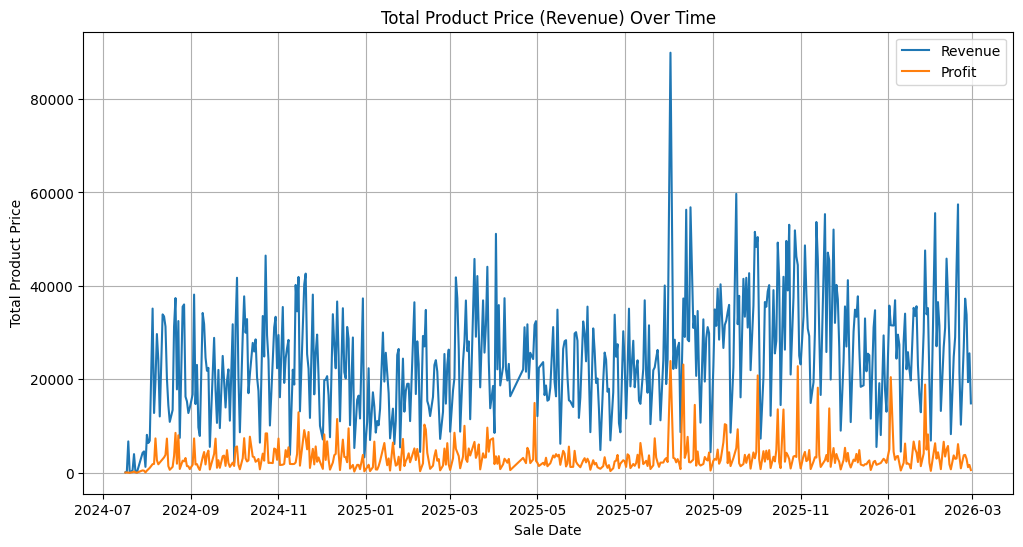

<Figure size 640x480 with 0 Axes>

In [42]:
# Convert 'sale_date' to datetime objects for proper time series plotting
df["sale_date"] = pd.to_datetime(df["sale_date"])

revenue = df.groupby("sale_date")["product_price"].sum().reset_index()
profit = df.groupby("sale_date")["unit_gross_profit"].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(revenue["sale_date"], revenue["product_price"])
plt.plot(profit["sale_date"], profit["unit_gross_profit"])

plt.title("Total Product Price (Revenue) Over Time")
plt.xlabel("Sale Date")
plt.ylabel("Total Product Price")
plt.legend(["Revenue", "Profit"])
plt.grid(True)
plt.show()
plt.savefig("revenue_vs_profit.png", dpi=150, bbox_inches="tight")

It can be see a certain Seasonality between Revenue and Profit

In [43]:
rules_1to1.to_csv("rules_1to1_with_profit.csv", index=False)
frequent_itemsets.to_csv("frequent_itemsets.csv", index=False)

print("\nSaved: rules_1to1_with_profit.csv, frequent_itemsets.csv")


Saved: rules_1to1_with_profit.csv, frequent_itemsets.csv


## Aggregate Incremental Profit


In [48]:
aggregated_incremental_profit = rules_1to1.groupby('consequent_id')['incremental_profit'].sum().reset_index()
aggregated_incremental_profit.rename(columns={'incremental_profit': 'total_incremental_profit'}, inplace=True)
print(aggregated_incremental_profit.head())

                          consequent_id  total_incremental_profit
0  4226259e-2c9c-4cfd-965a-d1b6d34a51e5                    0.0000
1  4fc56492-ce5a-4f2f-a88a-8911b4fc07b9               162042.6300
2  5dad6e40-4c14-4fd7-9e3a-e56bf1841cc0                51095.3895
3  e21e58f0-88b3-442c-af14-7b965a42ee39                 3250.4940


Now that the total incremental profit for each consequent product has been calculated, I will merge this information into the `product_summary` DataFrame. This will allow for the creation of a `future_profit` column, which combines the existing `total_profit` with the potential incremental profit.



In [60]:
product_summary = df.groupby('product_id').agg(
    total_profit=('unit_profit_used', 'sum'),
    product_name=('product_name', 'first')
).reset_index()

product_summary = product_summary.merge(aggregated_incremental_profit,
                                    left_on='product_id',
                                        right_on='consequent_id',
                                        how='left')

product_summary['total_incremental_profit'] = product_summary['total_incremental_profit'].fillna(0)

product_summary['future_profit'] = product_summary['total_profit'] + product_summary['total_incremental_profit']

print("Product Summary with Future Profit (head):")
print(product_summary.head())

Product Summary with Future Profit (head):
                             product_id  total_profit  \
0  0087a37b-07cf-4517-8e8a-31fa99332300    2669.45000   
1  035b8700-ec21-469c-a33a-d15c6273f754      31.67502   
2  03ef1ea3-11fe-4178-afe8-d1f7bc5da090       0.00000   
3  058ff848-3897-4e73-bcfc-ab131ed06e80       0.00000   
4  0903ff0d-4aa6-49cd-80ee-5c8d231ca679   56273.09000   

                   product_name consequent_id  total_incremental_profit  \
0        ANILLOS DE 1/4 12X16X4           NaN                       0.0   
1          BARRO BLOCK 20X30X20           NaN                       0.0   
2                   MIXTO VIAJE           NaN                       0.0   
3   VARILLA 1/2 PIEZA FERRETERO           NaN                       0.0   
4  CARGO POR ENTREGA 250 ZONA 2           NaN                       0.0   

   future_profit  
0     2669.45000  
1       31.67502  
2        0.00000  
3        0.00000  
4    56273.09000  


In [51]:
top_products_to_plot = product_summary.sort_values(by='future_profit', ascending=False).head(10)

print("Top 10 Products by Future Profit:")
print(top_products_to_plot[['product_name', 'total_profit', 'total_incremental_profit', 'future_profit']].to_string(index=False))

Top 10 Products by Future Profit:
                     product_name  total_profit  total_incremental_profit  future_profit
                CARGO POR ENTREGA   413948.2894                    0.0000    413948.2894
CEMENTO GRIS MONTERREY EXTRA 50KG   120348.1300               162042.6300    282390.7600
         SUMINISTRO DE MATERIALES   253753.0000                    0.0000    253753.0000
     CARGO POR ENTREGA 200 ZONA 1   180156.0800                51095.3895    231251.4695
       CARGO POR ENTREGA 300 ZONA    98626.9600                    0.0000     98626.9600
                   CEMENTO APASCO    79885.8500                    0.0000     79885.8500
               ARENA CRIBADA 40KG    66514.8600                    0.0000     66514.8600
           TRASLADO DE MAQUINARIA    57000.0000                    0.0000     57000.0000
     CARGO POR ENTREGA 250 ZONA 2    56273.0900                    0.0000     56273.0900
                 YESO MAXIMO 40KG    38397.8400                    0.0000   

# Visualization Total profit Vs Future Profit

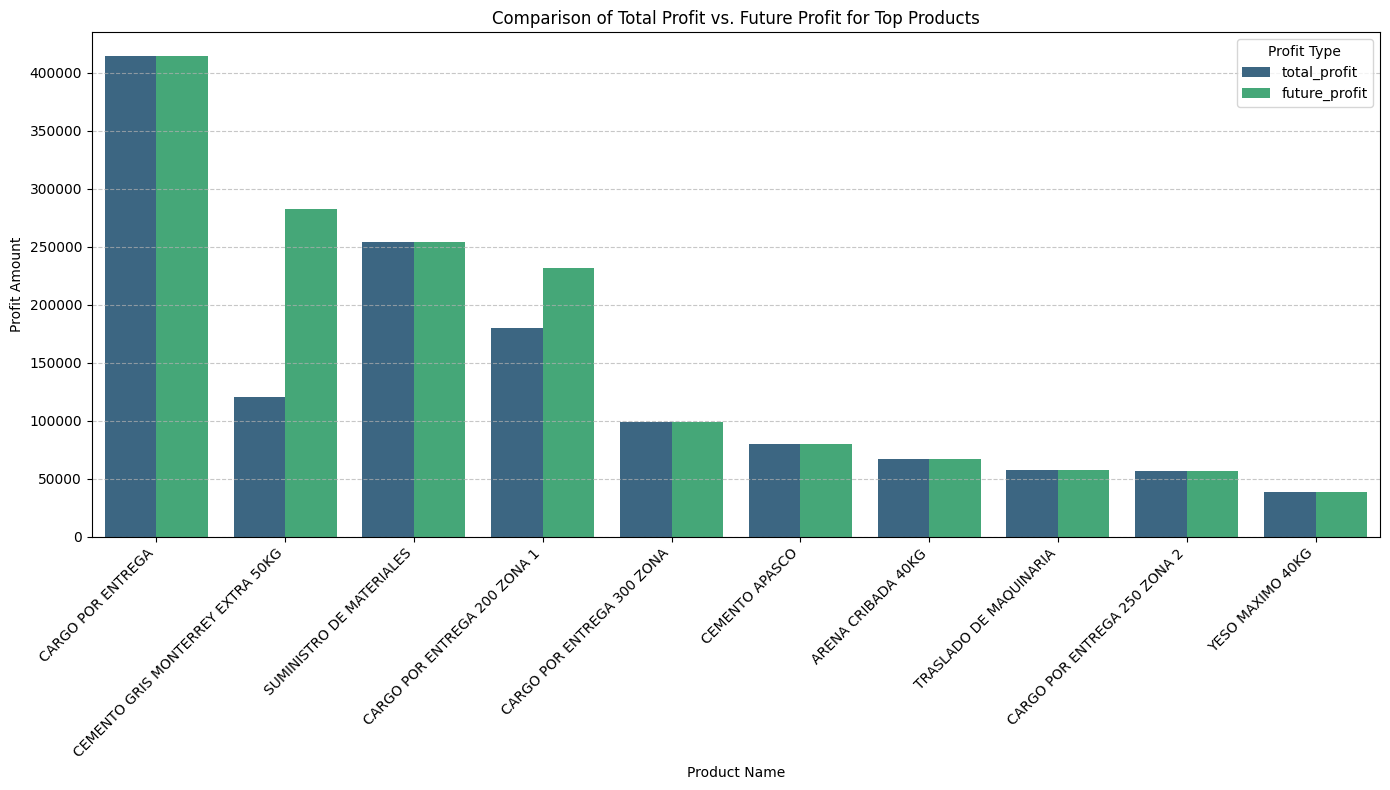

<Figure size 640x480 with 0 Axes>

In [52]:

# Melt the DataFrame for easier plotting
plot_data = top_products_to_plot.melt(id_vars=['product_name'],
                                      value_vars=['total_profit', 'future_profit'],
                                      var_name='Profit Type',
                                      value_name='Profit Amount')

plt.figure(figsize=(14, 8))
sns.barplot(x='product_name', y='Profit Amount', hue='Profit Type', data=plot_data, palette='viridis')
plt.title('Comparison of Total Profit vs. Future Profit for Top Products')
plt.xlabel('Product Name')
plt.ylabel('Profit Amount')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Profit Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
plt.savefig("future_profit.png", dpi=150, bbox_inches="tight")

This analysis confirms that cement acts as the anchor product within the portfolio, driving both transaction frequency and cross-product associations. Freight-related items also represent a critical profitability lever, particularly in bundle scenarios.

The bundle simulation suggests that targeted discounting strategies — especially when anchored to cement purchases — could unlock meaningful incremental profit without structurally reducing margins.

However, before operationalizing these recommendations, it is necessary to validate missing economic values (NaNs) in the dataset to ensure that the absence of projected future profit in certain high-lift products is not due to data gaps or pipeline inconsistencies in GCP.

Overall, the evidence points to clear, data-backed opportunities to strengthen margins through intelligent cross-selling, rather than volume-based discounting.